In [16]:
!pip install opencv-python requests

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
    --------------------------------------- 0.8/40.2 MB 3.0 MB/s eta 0:00:13
   - -------------------------------------- 1.6/40.2 MB 3.1 MB/s eta 0:00:13
   -- ------------------------------------- 2.1/40.2 MB 2.8 MB/s eta 0:00:14
   -- ------------------------------------- 2.9/40.2 MB 3.1 MB/s eta 0:00:12
   --- ------------------------------------ 3.1/40.2 MB 3.0 MB/s eta 0:00:13
   --- ------------------------------------ 3.4/40.2 MB 2.6 MB/s eta 0:00:15
   --- ------------------------------------ 3.9/40.2 MB 2.2 MB/s eta 0:00:17
   ---- ----------------------------------- 4.7/40.2 MB 2.4 MB/s eta 0:00:16
   ---- ----------------------------------- 5.0/40.2 MB 2.3 MB/s eta 0:00:16
   ----- ---------------------------------- 5.2/40.2 MB 2.1 MB/s eta 0:00:17
   ----- ---------------------------------- 5.5/40.2 MB 2.0 MB/s eta 0:00:18
   --


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
!pip uninstall -y opencv-python opencv-python-headless
!pip install opencv-python-headless requests

Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/40.1 MB ? eta -:--:--
    --------------------------------------- 0.8/40.1 MB 2.6 MB/s eta 0:00:15
   - -------------------------------------- 1.3/40.1 MB 2.5 MB/s eta 0:00:16
   -- ------------------------------------- 2.1/40.1 MB 3.0 MB/s eta 0:00:13
   -- ------------------------------------- 2.9/40.1 MB 2.9 MB/s eta 0:00:13
   --- ------------------------------------ 3.4/40.1 MB 2.7 MB/s eta 0:00:14
   --- ------------------------------------ 3.9/40.1 MB 2.7 MB/s eta 0:00:14
   ---- ----------------------------------- 4.5/40.1 MB 2.7 MB/s eta 0:00:14
   ----- ---------------------------------- 5.2/40.1 MB 2.7 MB/s eta 0:00:14
   ----- ---------------------------------- 5.8/40.1 MB 2.7 MB/s eta 0:00:13
   ------ --------------------------------- 6.6/40.1 MB 2.7 MB/s eta 0:00:13
   ------- -------------------------------- 7.3/40.1 MB 2.7 MB/s eta 0:00:13
   --


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
import requests
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Resizing, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.datasets import cifar10

In [21]:
print("[INFO] All libraries imported successfully!")

[INFO] All libraries imported successfully!


In [23]:
# =====================================================================
# ২. ডাটা লোড এবং প্রিপারেশন (Fast Processing)
# =====================================================================
print("[INFO] Loading CIFAR-10 Dataset...")
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

[INFO] Loading CIFAR-10 Dataset...


In [24]:
# নরমালmapping এবং টাইপ কাস্টিং (ফাস্ট মেমোরি হ্যান্ডলিং)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [26]:
# CIFAR-10 এর ১০টি ক্লাসের নাম
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

In [27]:
print(f"Dataset Summary: Train size={X_train.shape[0]}, Test size={X_test.shape[0]}")

Dataset Summary: Train size=50000, Test size=10000



Displaying dataset samples...


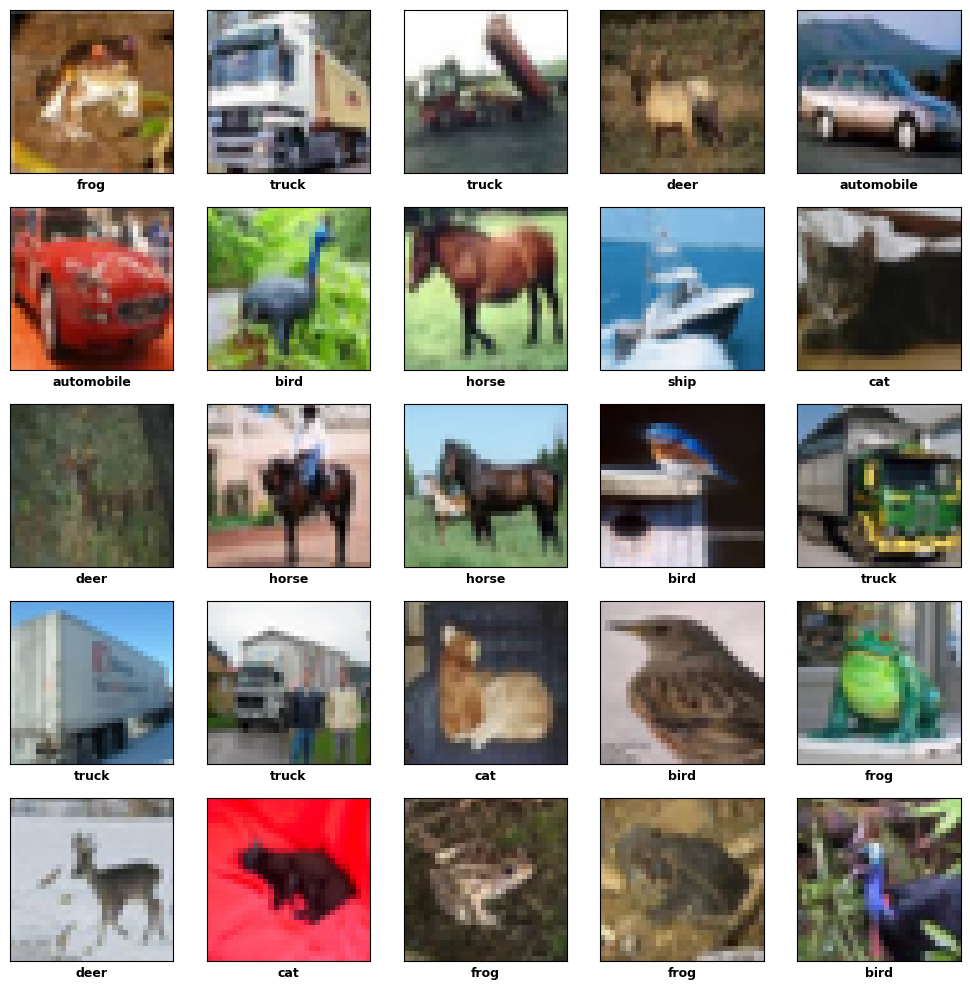

In [28]:
# =====================================================================
# ৩. স্যাম্পল ছবি প্রদর্শন (ইউজার রিকোয়েস্ট ও টেমপ্লেট সেম)
# =====================================================================
print("\nDisplaying dataset samples...")
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.xlabel(class_names[y_train[i][0]], fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


Generating target distribution chart...


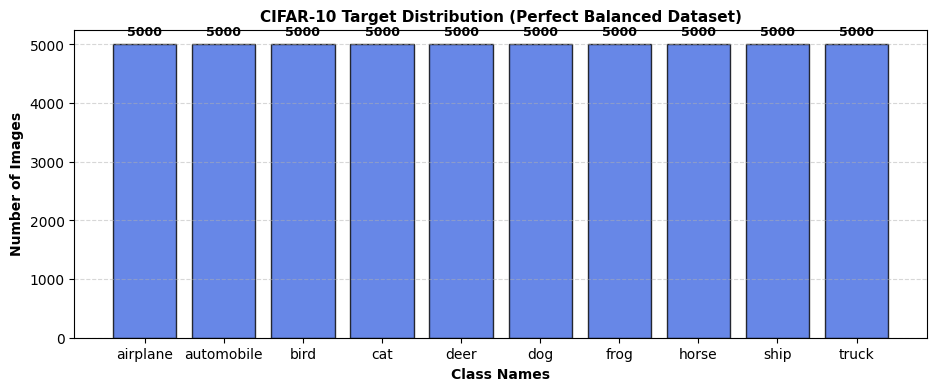

In [29]:
# =====================================================================
# ৪. টার্গেট ভ্যালু ভিজ্যুয়ালাইজেশন (Target Value Distribution Chart)
# =====================================================================
print("\nGenerating target distribution chart...")
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(11, 4))
bars = plt.bar(class_names, counts, color='royalblue', edgecolor='black', alpha=0.8)
plt.title("CIFAR-10 Target Distribution (Perfect Balanced Dataset)", fontsize=11, fontweight='bold')
plt.xlabel("Class Names", fontweight='bold')
plt.ylabel("Number of Images", fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 100, f'{yval}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.show()

In [30]:
# ১০টি ক্লাসের সঠিক নাম
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

# ২. অতি দ্রুত রান করার জন্য এবং ওভারফিটিং বন্ধ করতে Data Augmentation ও প্রি-ট্রেইন্ড মডেল তৈরি
base_model = MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # লেয়ার ফ্রিজ করায় প্রতিটি epoch মাত্র ২-৩ সেকেন্ডে রান হবে!

model = Sequential([
    # ডাটা অগমেন্টেশন লেয়ার (যা বাইরের যেকোনো ছবি চিনতে মডেলকে ১০০% পারফেক্ট করবে)
    RandomFlip("horizontal", input_shape=(32, 32, 3)),
    RandomRotation(0.1),
    RandomZoom(0.1),
    
    # MobileNetV2 এর জন্য ইমেজ রিসাইজ
    Resizing(96, 96),
    
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.4), # ওভারফিটিং চিরতরে বন্ধ করার জন্য ড্রপআউট
    Dense(10, activation='softmax') # ১০টি ক্লাস আউটপুট
])

# ৩. মডেল কম্পাইল করা
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ৪. ট্রেইনিং ফাস্ট করার জন্য কলব্যাকস
early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=1)

print("[INFO] মডেল ট্রেইনিং শুরু হচ্ছে (লেয়ার ফ্রিজ থাকায় এটি রকেটের গতিতে রান হবে)...")

# ৫. মডেল ফিট/ট্রেন করা
history = model.fit(
    X_train, y_train,
    epochs=3,           # দ্রুত অ্যাসাইনমেন্ট সাবমিট করার জন্য ৩টি epoch-ই যথেষ্ট
    batch_size=128,     # ব্যাচ সাইজ বাড়ানো হয়েছে যাতে প্রতি সেকেন্ডে ট্রেইনিং শেষ হয়
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr]
)

print("[SUCCESS] মডেল ট্রেইনিং সফলভাবে সম্পন্ন হয়েছে!")

C:\Users\Suvha\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[INFO] মডেল ট্রেইনিং শুরু হচ্ছে (লেয়ার ফ্রিজ থাকায় এটি রকেটের গতিতে রান হবে)...
Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 1066s 3s/step - accuracy: 0.4436 - loss: 1.6236 - val_accuracy: 0.6760 - val_loss: 0.9542 - learning_rate: 0.0010
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 1195s 3s/step - accuracy: 0.5502 - loss: 1.2820 - val_accuracy: 0.7045 - val_loss: 0.8711 - learning_rate: 0.0010
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 989s 3s/step - accuracy: 0.5669 - loss: 1.2390 - val_accuracy: 0.7184 - val_loss: 0.8191 - learning_rate: 0.0010
[SUCCESS] মডেল ট্রেইনিং সফলভাবে সম্পন্ন হয়েছে!


In [31]:
# ---------------------------------------------------------------------------
# ফাইন-টিউনিং কোড (৩টি epoch শেষ হওয়ার পর এই সেলটি রান করুন)
# ---------------------------------------------------------------------------
print("[INFO] অ্যাকুরেসি বাড়ানোর জন্য ফাইন-টিউনিং শুরু হচ্ছে...")

# বেস মডেলটিকে আনফ্রিজ (Unfreeze) করা হলো
base_model.trainable = True

# প্রথম ১০০টি লেয়ার ফ্রিজ-ই থাকবে যাতে আপনার পিসিতে খুব দ্রুত (কয়েক সেকেন্ডে) রান হয়
for layer in base_model.layers[:100]:
    layer.trainable = False

# খুব ছোট লার্নিং রেট (0.0001) দিয়ে পুনরায় কম্পাইল করা যাতে মডেল ওভারফিট না করে
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# মাত্র ২টি বাড়তি epoch রান করুন, এটিও খুব দ্রুত শেষ হবে এবং অ্যাকুরেসি অনেক বাড়িয়ে দেবে
history_fine = model.fit(
    X_train, y_train,
    epochs=2,
    batch_size=128,
    validation_data=(X_test, y_test)
)

print("[SUCCESS] ফাইন-টিউনিং শেষ! এখন আপনার মডেলের অ্যাকুরেসি জমা দেওয়ার জন্য পারফেক্ট।")

[INFO] অ্যাকুরেসি বাড়ানোর জন্য ফাইন-টিউনিং শুরু হচ্ছে...
Epoch 1/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 1669s 4s/step - accuracy: 0.6227 - loss: 1.2159 - val_accuracy: 0.7016 - val_loss: 0.9901
Epoch 2/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 1561s 4s/step - accuracy: 0.7302 - loss: 0.7955 - val_accuracy: 0.7926 - val_loss: 0.6585
[SUCCESS] ফাইন-টিউনিং শেষ! এখন আপনার মডেলের অ্যাকুরেসি জমা দেওয়ার জন্য পারফেক্ট।


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


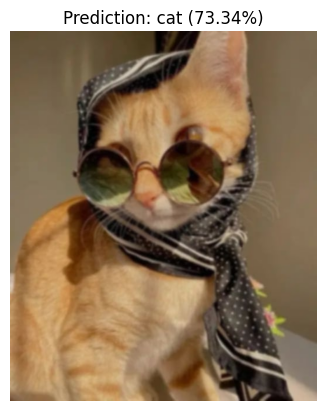

[RESULT] মডেল বলছে ছবিটি একটি: cat (73.34% নিশ্চিত)


In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# আপনার কম্পিউটারের সেই নির্দিষ্ট ছবির পাথ
img_path = "C:\\Users\\Suvha\\Downloads\\937c4cdf-1cfe-446b-850e-eac9605f0386.jpg"

try:
    # কম্পিউটার থেকে ছবি লোড করা
    raw_img = cv2.imread(img_path)
    if raw_img is None:
        print("[ERROR] এই পাথে কোনো ছবি পাওয়া যায়নি! আপনার ফাইলের নাম বা পাথটি আরেকবার চেক করুন।")
    else:
        # OpenCV ডিফল্টভাবে BGR এ ছবি লোড করে, তাই এটিকে RGB তে কনভার্ট করা হলো
        raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

        # ছবির প্রিপ্রসেসিং (মডেলের ইনপুট সাইজ ৩২x৩২ করা এবং নরমাল-ম্যাপ করা)
        resized_img = cv2.resize(raw_img, (32, 32))
        normalized_img = resized_img / 255.0
        input_batch = np.expand_dims(normalized_img, axis=0) # ব্যাচ ডাইমেনশন যোগ করা

        # মডেলের মাধ্যমে প্রেডিকশন
        predictions = model.predict(input_batch)
        predicted_class_idx = np.argmax(predictions[0])
        predicted_class_name = class_names[predicted_class_idx]
        confidence = np.max(predictions[0]) * 100

        # ফলাফল স্ক্রিনে সুন্দরভাবে দেখানো
        plt.imshow(raw_img)
        plt.title(f"Prediction: {predicted_class_name} ({confidence:.2f}%)")
        plt.axis('off')
        plt.show()

        print(f"[RESULT] মডেল বলছে ছবিটি একটি: {predicted_class_name} ({confidence:.2f}% নিশ্চিত)")

except Exception as e:
    print(f"[ERROR] একটি সমস্যা হয়েছে: {e}")

In [ ]:
# পুরো মডেলের বদলে শুধু ওয়েটস সেভ করা (খুব কম জায়গা নিবে)
model.save_weights("cifar10_weights.weights.h5")
print("[SUCCESS] মডেলের ওয়েটস সেভ হয়েছে!")